In [1]:
# Importing relevant libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

In [2]:
# Load dataset
df = pd.read_csv(r"C:\Amit Dubli\VS code\Assignment 4\data\q3_retail_promotions.csv", parse_dates=["transaction_date"])

In [3]:
# Sort by date (useful later as well)
df = df.sort_values("transaction_date")

In [4]:
# Feature engineering
df["year"] = df["transaction_date"].dt.year
df["month"] = df["transaction_date"].dt.month
df["day_of_week"] = df["transaction_date"].dt.dayofweek

In [5]:
# Month-end feature
df["is_month_end"] = (df["transaction_date"].dt.day >= 25).astype(int)

In [6]:
# Display sample
print(df.head())

  transaction_date  store_id store_size location_type  promotion_type  \
0       2022-01-01        28      small    semi-urban       free_gift   
1       2022-01-01         5     medium    semi-urban       free_gift   
2       2022-01-02        13      small    semi-urban  loyalty_points   
3       2022-01-02        17      small         urban       free_gift   
4       2022-01-03        50     medium    semi-urban            bogo   

   is_weekend  is_festival  competition_density  items_sold  year  month  \
0           1            0                    5         224  2022      1   
1           1            1                    1         348  2022      1   
2           1            0                    6         249  2022      1   
3           1            0                    7         259  2022      1   
4           0            0                    3         277  2022      1   

   day_of_week  is_month_end  
0            5             0  
1            5             0  
2          

In [7]:
# Split index
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

print("Train size:", train_df.shape)
print("Test size:", test_df.shape)

Train size: (960, 13)
Test size: (240, 13)


In [8]:
# Selecting Target and other features
target = "items_sold"

# Dividing test and train data of target
X_train = train_df.drop(columns=[target, "transaction_date"])
y_train = train_df[target]

X_test = test_df.drop(columns=[target, "transaction_date"])
y_test = test_df[target]

In [9]:
# Grouping columns in numerical and categorical

categorical_cols = ["promotion_type", "location_type", "store_size"]
numeric_cols = [col for col in X_train.columns if col not in categorical_cols]

In [10]:
# Preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numeric_cols)
    ]
)

In [11]:
# Builing pipeline using linear regression

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# Train
lr_pipeline.fit(X_train, y_train)

# Predict
y_pred_lr = lr_pipeline.predict(X_test)

# Metrics
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression MAE:", mae_lr)

Linear Regression RMSE: 27.192398890383632
Linear Regression MAE: 21.082096354166666


In [12]:
# Builing pipeline using Random forest

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=100, random_state=42))
])

# Train
rf_pipeline.fit(X_train, y_train)

# Predict
y_pred_rf = rf_pipeline.predict(X_test)

# Metrics
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest MAE:", mae_rf)

Random Forest RMSE: 30.841610008504205
Random Forest MAE: 24.240625


By the two outputs above we can see that RMSE is more for Random forest than linear regression and MAE is also greater in Random forest than linear regression, this all implies that Linear Regression outperforms Random Forest as it has lower RMSE and MAE, indicating more accurate predictions. This suggests that the underlying relationship in the data is likely linear, making Linear Regression a better choice.

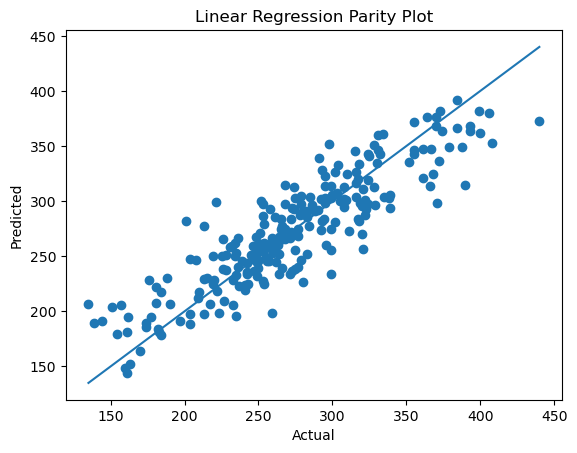

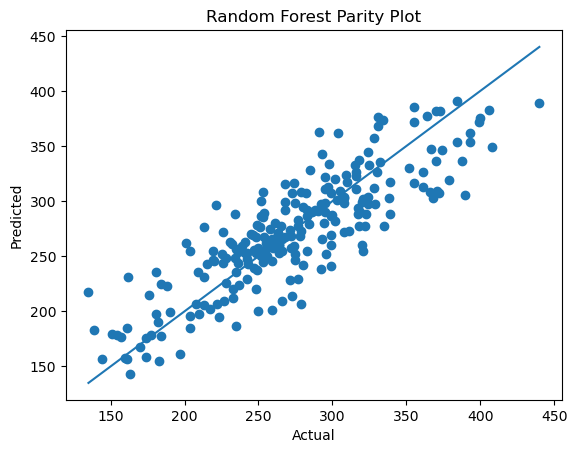

In [13]:
# Building parity plots to compare actual vs predicted values, where closeness to the diagonal line indicates better model 
# accuracy.

def parity_plot(y_true, y_pred, title):
    plt.figure()
    plt.scatter(y_true, y_pred)
    
    # Diagonal line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val])
    
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.show()

# Plots
parity_plot(y_test, y_pred_lr, "Linear Regression Parity Plot")
parity_plot(y_test, y_pred_rf, "Random Forest Parity Plot")

Linear Regression performs slightly better because its predictions are more tightly clustered around the diagonal line.
whereas Random Forest shows more spread, indicating slightly higher errors.
This suggests that the relationship in the data is likely more linear than complex/non-linear.

In [14]:
# Get feature names after preprocessing
ohe = rf_pipeline.named_steps["preprocessor"].named_transformers_["cat"]
encoded_cat_features = ohe.get_feature_names_out(categorical_cols)

all_features = list(encoded_cat_features) + numeric_cols

# Importances
importances = rf_pipeline.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": all_features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(feature_importance_df.head(5))

                feature  importance
13          is_festival    0.173473
10     store_size_small    0.167683
7   location_type_urban    0.108378
17          day_of_week    0.086316
12           is_weekend    0.061208


1. As is_festival is 17.35% means sales increase significantly during festival periods.
2. Next comes store_size_small with 16.77% means smaller stores may have higher or more consistent sales.
3. location_type_urban is having b10.8% meaning stores in urban areas tend to have more sales.
4. Rest days and weekend influence the sales.